In [3]:
# 1. Load and preprocess image
from skimage import io, exposure
import numpy as np

img_path = "C:/Users/Acer/Downloads/real_data/real_data/Figure7_2D_3D/2D/22_Pr01_0_594.tif"
img = io.imread(img_path)
print("Image shape:", img.shape)

# Normalize each channel
channels = [exposure.rescale_intensity(img[..., i], out_range=(0,1)) for i in range(img.shape[-1])]
ch1, ch2, ch3 = channels

Image shape: (1440, 1432, 3)


In [5]:
# 2. Visualize in Napari
%gui qt
import napari

viewer = napari.Viewer()
colors = ["red", "green", "blue"]

# Add each channel
for i, ch in enumerate(channels):
    viewer.add_image(ch, name=f"Channel {i+1}", colormap=colors[i], blending="additive")

# Create overlay mask for visual colocalization
coloc_mask = (ch1 > 0.3) & (ch2 > 0.3)
viewer.add_labels(coloc_mask.astype(np.uint8), name="Colocalization (yellow)", color={1: "yellow"})

napari.run()


C:\Users\Acer\anaconda3\envs\napari_env\lib\site-packages\napari\components\viewer_model.py:10: FutureWarning: Labels.color is deprecated since 0.4.19 and will be removed in 0.5.0, please set Labels.colormap directly with an instance of napari.utils.colormaps.DirectLabelColormap instead.
  TYPE_CHECKING,


In [7]:
# 3. Quantitative Colocalization Metrics
from scipy.stats import pearsonr
import ot
import matplotlib.pyplot as plt

# Helper functions
def pearson_coeff(ch1, ch2):
    return pearsonr(ch1.ravel(), ch2.ravel())[0]

def manders_coeff(ch1, ch2):
    return np.sum(ch1[ch2 > 0]) / np.sum(ch1)

def to_distribution(channel, eps=1e-9):
    x = channel.ravel().astype(float)
    x = np.maximum(x, 0)
    total = np.sum(x)
    if total == 0:
        return np.ones_like(x) / len(x)
    return (x + eps) / (total + eps*len(x))

def cost_matrix(shape):
    h, w = shape
    coords = np.array([(i % w, i // w) for i in range(h*w)])
    C = ot.dist(coords, coords)
    return C / C.max()

def compute_otc_curve(ch1, ch2, num_scales=5, reg=0.1):
    x1, x2 = to_distribution(ch1), to_distribution(ch2)
    C = cost_matrix(ch1.shape)
    scales = np.linspace(0.5, 2.0, num_scales)
    otc_vals = []
    for t in scales:
        Ct = C * t
        plan = ot.sinkhorn(x1, x2, Ct, reg=reg)
        otc_vals.append(np.sum(plan * Ct))
    return scales, otc_vals

In [9]:
# 4. Select ROI automatically (avoids empty region issues)
def find_nonempty_roi(ch1, ch2, size=128, min_sum=50):
    h, w = ch1.shape
    for i in range(0, h-size, size):
        for j in range(0, w-size, size):
            roi1 = ch1[i:i+size, j:j+size]
            roi2 = ch2[i:i+size, j:j+size]
            if np.sum(roi1) > min_sum and np.sum(roi2) > min_sum:
                return roi1, roi2
    return None, None

roi_ch1, roi_ch2 = find_nonempty_roi(ch1, ch2)
if roi_ch1 is None:
    raise ValueError("No suitable ROI found. Try another region with signal.")


In [11]:
# 5. Compute metrics and plot 
pearson_val = pearson_coeff(roi_ch1, roi_ch2)
manders_val = manders_coeff(roi_ch1, roi_ch2)
scales, otc_vals = compute_otc_curve(roi_ch1, roi_ch2)

# Plot
plt.figure(figsize=(6,4))
plt.plot(scales, otc_vals, '-o', label="OTC(t)")
plt.axhline(y=pearson_val, color='r', linestyle='--', label=f"Pearson = {pearson_val:.3f}")
plt.axhline(y=manders_val, color='g', linestyle='-.', label=f"Manders = {manders_val:.3f}")
plt.xlabel("Scale (t)")
plt.ylabel("Colocalization Score")
plt.title("Colocalization Metrics Comparison")
plt.legend()
plt.show()

print(f"Pearson: {pearson_val:.3f}")
print(f"Manders: {manders_val:.3f}")
print("OTC values:", np.round(otc_vals, 5))

MemoryError: Unable to allocate 1.00 GiB for an array with shape (16384, 16384) and data type int32

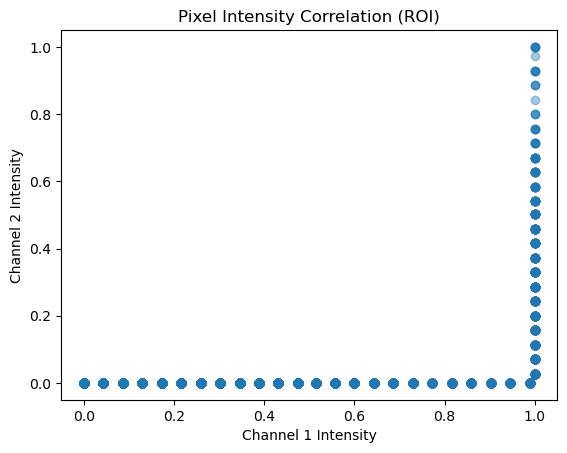

In [11]:
plt.scatter(roi_ch1.ravel(), roi_ch2.ravel(), alpha=0.4)
plt.xlabel("Channel 1 Intensity")
plt.ylabel("Channel 2 Intensity")
plt.title("Pixel Intensity Correlation (ROI)")
plt.show()